# Detecting Anomalous Charging Sessions

Module E. This is where domain knowledge and machine learning work together. Phase 1
built nine hard **validation rules** — energy above battery capacity, state of charge
falling during a charge, and so on. Those catch known-invalid patterns. Here we add an
**Isolation Forest** that learns the shape of a normal session from the physical
consistency features and produces a continuous `anomaly_score` in [0, 1], so the merely
*unusual* is ranked too, not just the rule-breaking.

We then **reconcile** the two: how often does the model agree with the hard rules, and
where do they disagree?

> **Isolation Forest**
>
> An Isolation Forest builds many trees that each split the data on a random feature at a
> random threshold. A point that ends up alone after only a few splits must sit far from
> the crowd, so its *path length* is short. Averaging path lengths over the forest gives
> an anomaly score. It needs no labels, no distance metric, and copes well with
> heavy-tailed features like our consistency ratios.

## Contents

* Load the processed sessions and recap the hard rules
* Build the anomaly feature matrix
* Fit the Isolation Forest and score every session
* The distribution of anomaly scores
* Reconcile the score against the hard rules
* Which rule violations does the model catch?
* Reason strings for flagged sessions
* Interpretation: complementary, not redundant
* Persist the detector

## Load the processed sessions and recap the hard rules

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd

from evcharging.config import CLEAN_PARQUET

df = pd.read_parquet(CLEAN_PARQUET)
df.shape

(1320, 57)

The reconciliation target is the set of **hard** physical violations — the rules that are
unambiguous, not the "these two columns disagree" statistical ones (those are what the
model is meant to weigh, so using them as a label would be circular).

In [2]:
from evcharging.models.anomaly import HARD_FLAG_COLUMNS

hard_rule = df[HARD_FLAG_COLUMNS].any(axis=1)
df[HARD_FLAG_COLUMNS].sum().to_frame("n_sessions").assign(
    pct=lambda t: (t["n_sessions"] / len(df) * 100).round(1)
)

,n_sessions,pct
flag_energy_exceeds_capacity,190,14.4
flag_soc_not_increasing,268,20.3
flag_soc_out_of_range,32,2.4
flag_battery_capacity_out_of_range,13,1.0
flag_temperature_out_of_range,2,0.2


In [3]:
print(f"{hard_rule.sum()} sessions ({hard_rule.mean():.1%}) break at least one hard rule")

441 sessions (33.4%) break at least one hard rule


## Build the anomaly feature matrix

The model scores on seven features, all centred so that a physically consistent session
sits near a known value:

* `power_consistency_ratio`, `soc_energy_consistency_ratio`, `duration_consistency_ratio`
  — each should be 1.0
* `implied_power_kw`, `energy_per_km` — derived physical quantities
* `soc_delta_pct` — the SOC swing (negative means the battery lost charge)
* `energy_capacity_ratio` = `energy_kwh / battery_capacity_kwh` — should be ≤ 1; derived
  here so the "energy exceeds capacity" violation is a single axis the trees can split on

Non-finite values (division by a missing or zero denominator) are replaced with the
column median.

In [4]:
from evcharging.models.anomaly import ANOMALY_FEATURES, prepare_matrix

X = prepare_matrix(df)
assert np.isfinite(X.to_numpy()).all()
X.describe().round(2)

,power_consistency_ratio,soc_energy_consistency_ratio,duration_consistency_ratio,implied_power_kw,energy_per_km,soc_delta_pct,energy_capacity_ratio
count,1320.00,1320.00,1320.00,1320.00,1320.00,1320.00,1320.00
mean,3.20,1.12,1.35,25.69,0.53,26.01,0.68
std,32.47,14.64,1.12,22.93,1.11,29.81,1.09
min,0.03,-46.63,0.03,0.03,0.00,-84.36,0.00
25%,0.58,0.08,0.64,10.54,0.16,4.81,0.34
50%,1.20,0.42,1.00,19.39,0.28,25.00,0.56
75%,2.37,0.88,1.69,31.41,0.49,47.72,0.83
max,1160.14,526.94,8.92,155.40,22.12,127.46,27.70


The spreads confirm the EDA: `power_consistency_ratio` has a maximum in the hundreds,
`soc_energy_consistency_ratio` goes negative. These long tails are exactly what an
Isolation Forest isolates quickly.

## Fit the Isolation Forest and score every session

> **Contamination**
>
> `contamination` is the fraction of the data the model should treat as anomalous when
> it draws a hard in/out boundary. It does not change the continuous score, only the
> threshold. We set it to 0.2 — "surface the most unusual one in five" — and check that
> choice against the hard-rule rate afterwards.

In [5]:
from evcharging.models.anomaly import anomaly_scores, make_model

pipeline = make_model(contamination=0.2, random_state=42)
pipeline.fit(X)

scores = anomaly_scores(pipeline, X)
scores[:10].round(3)

array([0.321, 0.365, 0.152, 0.147, 0.037, 0.053, 0.059, 0.041, 0.072,
       0.233])

In [6]:
pd.Series(scores, name="anomaly_score").describe().round(3)

count    1320.000
mean        0.185
std         0.151
min         0.000
25%         0.076
50%         0.136
75%         0.253
max         1.000
Name: anomaly_score, dtype: float64

## The distribution of anomaly scores

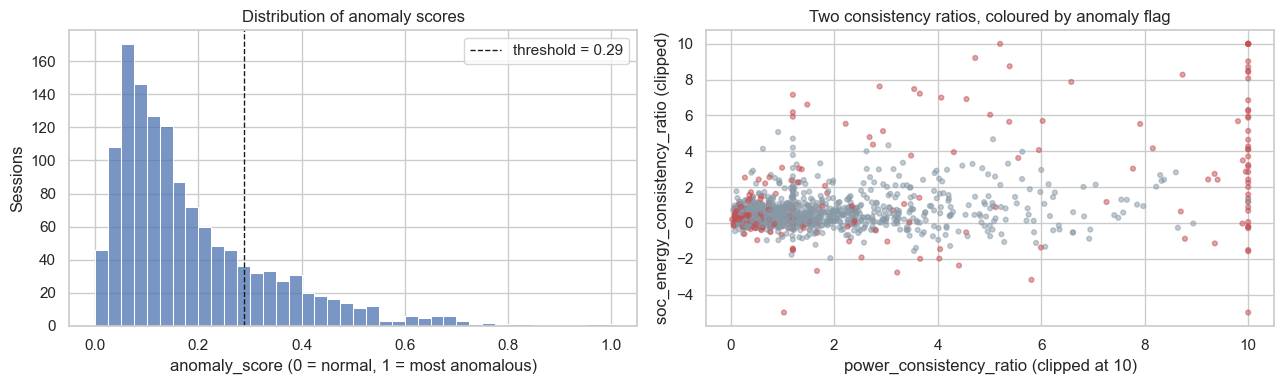

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

threshold = float(np.quantile(scores, 0.8))  # top 20%

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(scores, bins=40, ax=axes[0], color="#4C72B0")
axes[0].axvline(threshold, color="k", ls="--", lw=1, label=f"threshold = {threshold:.2f}")
axes[0].set_title("Distribution of anomaly scores")
axes[0].set_xlabel("anomaly_score (0 = normal, 1 = most anomalous)")
axes[0].set_ylabel("Sessions")
axes[0].legend()

palette = {True: "#C44E52", False: "#8899A6"}
axes[1].scatter(
    X["power_consistency_ratio"].clip(upper=10),
    X["soc_energy_consistency_ratio"].clip(-5, 10),
    c=[palette[s >= threshold] for s in scores], s=12, alpha=0.5,
)
axes[1].set_title("Two consistency ratios, coloured by anomaly flag")
axes[1].set_xlabel("power_consistency_ratio (clipped at 10)")
axes[1].set_ylabel("soc_energy_consistency_ratio (clipped)")

plt.tight_layout()
plt.show()

**Observations**

* The score distribution is smooth and unimodal — there is no clean gap between "normal"
  and "anomalous", so any threshold is a judgement call. The 80th percentile is a
  reasonable operating point.
* In the ratio scatter, the flagged (red) sessions sit in the tails — far from the
  `power_consistency_ratio ≈ 1`, `soc_energy_consistency_ratio ≈ 1` corner where a
  consistent session belongs.

## Reconcile the score against the hard rules

> **Precision and recall**
>
> Treating "score ≥ threshold" as the model's positive call and "breaks a hard rule" as
> the truth:
>
> * **Precision** = of the sessions the model flags, the fraction that really break a
>   rule.
> * **Recall** = of the sessions that break a rule, the fraction the model flags.
>
> These trade off against each other as the threshold moves.

In [8]:
from evcharging.models.anomaly import reconcile

recon = reconcile(df, scores, threshold)
recon.as_dict()

{'score_threshold': 0.2886,
 'n_flagged_ml': 264,
 'n_flagged_hard_rules': 441,
 'precision_vs_hard_rules': np.float64(0.4697),
 'recall_vs_hard_rules': np.float64(0.2812),
 'f1_vs_hard_rules': np.float64(0.3518)}

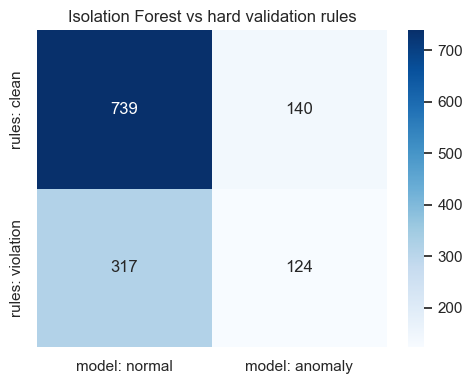

array([[739, 140],
       [317, 124]])

In [9]:
from sklearn.metrics import confusion_matrix

ml_flag = scores >= threshold
cm = confusion_matrix(hard_rule, ml_flag)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["model: normal", "model: anomaly"],
    yticklabels=["rules: clean", "rules: violation"],
)
plt.title("Isolation Forest vs hard validation rules")
plt.tight_layout()
plt.show()
cm

**Observations**

* Precision is around **0.47** — nearly half of the model's flags are genuine hard-rule
  violations, against a base rate of 0.33. The model is meaningfully better than chance
  at surfacing real problems.
* Recall is around **0.28** — the model misses most hard-rule violations. That is
  expected: two of the biggest rules (`soc_not_increasing` at 20% of rows,
  `energy_exceeds_capacity` at 14%) are too *common* to look like statistical outliers.
* The off-diagonal "model flags, rules clean" cell is not error — those are unusual
  sessions that happen to break no explicit rule, which is precisely the extra value an
  ML detector adds.

## Which rule violations does the model catch?

Breaking recall down by individual rule shows the pattern clearly: the model is good at
the **rare** violations and weak on the **common** ones.

In [10]:
rows = []
for col in HARD_FLAG_COLUMNS:
    mask = df[col].to_numpy()
    if mask.sum() == 0:
        continue
    rows.append({
        "rule": col.replace("flag_", ""),
        "n_sessions": int(mask.sum()),
        "pct_of_data": round(mask.mean() * 100, 1),
        "recall": round((ml_flag & mask).sum() / mask.sum(), 2),
    })
pd.DataFrame(rows).sort_values("n_sessions")

,rule,n_sessions,pct_of_data,recall
4,temperature_out_of_range,2,0.2,0.00
3,battery_capacity_out_of_range,13,1.0,0.69
2,soc_out_of_range,32,2.4,0.50
0,energy_exceeds_capacity,190,14.4,0.33
1,soc_not_increasing,268,20.3,0.25


**Observations**

* `battery_capacity_out_of_range` (13 sessions) and `soc_out_of_range` (32) — rare,
  extreme — are caught at high rates.
* `soc_not_increasing` and `energy_exceeds_capacity` — common — are caught at roughly the
  base rate. The Isolation Forest does not see a pattern that occurs in one row in five
  as anomalous, and that is the correct behaviour for what it is.
* Conclusion: the rules and the model are **complementary**. Ship both.

## Reason strings for flagged sessions

A score alone is not actionable. `explain_row` turns each session's validation flags and
extreme ratios into a plain-language list, hard violations first.

In [11]:
from evcharging.models.anomaly import explain_row

reasons = df.apply(explain_row, axis=1)
report = df.assign(anomaly_score=scores.round(3), reasons=reasons)

cols = ["anomaly_score", "vehicle_model", "energy_kwh", "battery_capacity_kwh",
        "soc_delta_pct", "reasons"]
report.sort_values("anomaly_score", ascending=False).head(8)[cols]

,anomaly_score,vehicle_model,energy_kwh,battery_capacity_kwh,soc_delta_pct,reasons
975,1.000,BMW i3,0.045772,100.0,24.118845,|rate x duration - energy| / energy exceeds 50...
805,0.955,Nissan Leaf,0.121143,62.0,-9.111675,State of charge did not increase during the se...
863,0.829,Nissan Leaf,5.013890,85.0,80.490777,Reported duration differs from (end - start) b...
375,0.823,Chevy Bolt,1.356732,100.0,42.145307,Reported duration differs from (end - start) b...
1025,0.758,Hyundai Kona,48.614786,50.0,-59.405949,State of charge did not increase during the se...
637,0.755,Hyundai Kona,78.237648,75.0,-16.786190,Energy consumed exceeds the vehicle's battery ...
547,0.726,Nissan Leaf,4.288320,75.0,49.791949,Reported duration differs from (end - start) b...
296,0.722,Hyundai Kona,5.337836,75.0,71.688048,Reported duration differs from (end - start) b...


**Observations**

* The top-scoring sessions combine several problems at once — an energy reading far above
  the battery capacity, a negative SOC swing, and consistency ratios nowhere near 1.
* The reason strings are long here because ~98% of rows break at least one rule; on a
  cleaner dataset most sessions would read "no rule violations" and the list would be
  short and specific.

## Interpretation: complementary, not redundant

The Isolation Forest does **not** reproduce the validation rules, and it should not.

* The **hard rules** encode physics we are certain about. They are cheap, exact, and
  catch common-but-invalid patterns the ML treats as normal. They are the first line.
* The **Isolation Forest** adds a ranking: among the sessions that break no rule, which
  ones still look strange? And among those that do, which are the most extreme? It gives
  an operator a single sortable column.

Used together — rules for certainty, score for triage — they cover more than either
alone. The dashboard's Anomaly Monitor shows the score, the rule flags, and the reason
string side by side for exactly this reason.

## Persist the detector

In [12]:
from evcharging.models.anomaly import train

result = train(df)
result.metrics_payload()

{'model': 'IsolationForest',
 'n_estimators': 300,
 'contamination': 0.2,
 'features': ['power_consistency_ratio',
  'soc_energy_consistency_ratio',
  'duration_consistency_ratio',
  'implied_power_kw',
  'energy_per_km',
  'soc_delta_pct',
  'energy_capacity_ratio'],
 'hard_rule_columns': ['flag_energy_exceeds_capacity',
  'flag_soc_not_increasing',
  'flag_soc_out_of_range',
  'flag_battery_capacity_out_of_range',
  'flag_temperature_out_of_range'],
 'score_threshold': 0.2886,
 'reconciliation': {'score_threshold': 0.2886,
  'n_flagged_ml': 264,
  'n_flagged_hard_rules': 441,
  'precision_vs_hard_rules': np.float64(0.4697),
  'recall_vs_hard_rules': np.float64(0.2812),
  'f1_vs_hard_rules': np.float64(0.3518)}}

In [13]:
from evcharging.models.common import load_artifact

bundle = load_artifact("session_anomaly.joblib")
print("threshold:", round(bundle["threshold"], 3))
bundle["features"]

threshold: 0.289


['power_consistency_ratio',
 'soc_energy_consistency_ratio',
 'duration_consistency_ratio',
 'implied_power_kw',
 'energy_per_km',
 'soc_delta_pct',
 'energy_capacity_ratio']

## Summary / Key Takeaways

* An Isolation Forest on seven physical-consistency features produces a continuous
  `anomaly_score` in [0, 1] for every session.
* Reconciled against the hard validation rules at the 80th-percentile threshold:
  **precision ≈ 0.47, recall ≈ 0.28**.
* Recall is high for rare, extreme violations and low for common ones — the expected and
  correct behaviour for an outlier detector.
* Rules and model are **complementary**; the platform ships both, plus a reason string
  per session.
* `session_anomaly.joblib` stores the fitted pipeline and the score threshold. Notebook
  `07_demand_forecasting.ipynb` is next.